### Evluate the Segmentation Models

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
os.chdir("..")  # go to project root
print(f"cwd: {os.getcwd()}")  # sanity check

cwd: /home/dude-desktop/dev/taming-transformers


In [3]:
from main import instantiate_from_config, DataModuleFromConfig
from omegaconf import OmegaConf
import numpy as np
from tqdm.notebook import tqdm
import torch
import json
import torchmetrics
from PIL import Image
from taming.models.vqgan import VQSegmentationModel
import torch.nn.functional as F
from tqdm import tqdm
import matplotlib.pyplot as plt
import csv

In [4]:
DATA_CONFIG = """
target: main.DataModuleFromConfig
params:
    num_workers: 0
    batch_size: 8
    train:
      target: taming.data.coco.CocoImagesAndCaptionsTrain
      params:
        size: 296
        crop_size: 256
        onehot_segmentation: true
        use_stuffthing: true
    validation:
      target: taming.data.coco.CocoImagesAndCaptionsValidation
      params:
        size: 256
        crop_size: 256
        onehot_segmentation: true
        use_stuffthing: true
"""

data_cfg = OmegaConf.create(DATA_CONFIG)
data: DataModuleFromConfig = instantiate_from_config(data_cfg)
data.prepare_data()
data.setup()
train_ldr = data.train_dataloader()
val_ldr = data.val_dataloader()

ImgToCaptions: 100%|██████████| 25014/25014 [00:00<00:00, 1379425.18it/s]


In [5]:
with open("data/cocostuffthings/labels.txt", "r") as f:
    labels = [line.strip().split(": ")[1] for line in f.readlines()]
print(labels)

['unlabeled', 'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus', 'train', 'truck', 'boat', 'traffic light', 'fire hydrant', 'street sign', 'stop sign', 'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse', 'sheep', 'cow', 'elephant', 'bear', 'zebra', 'giraffe', 'hat', 'backpack', 'umbrella', 'shoe', 'eye glasses', 'handbag', 'tie', 'suitcase', 'frisbee', 'skis', 'snowboard', 'sports ball', 'kite', 'baseball bat', 'baseball glove', 'skateboard', 'surfboard', 'tennis racket', 'bottle', 'plate', 'wine glass', 'cup', 'fork', 'knife', 'spoon', 'bowl', 'banana', 'apple', 'sandwich', 'orange', 'broccoli', 'carrot', 'hot dog', 'pizza', 'donut', 'cake', 'chair', 'couch', 'potted plant', 'bed', 'mirror', 'dining table', 'window', 'desk', 'toilet', 'door', 'tv', 'laptop', 'mouse', 'remote', 'keyboard', 'cell phone', 'microwave', 'oven', 'toaster', 'sink', 'refrigerator', 'blender', 'book', 'clock', 'vase', 'scissors', 'teddy bear', 'hair drier', 'toothbrush', 'hair brush', 'banner', 

In [6]:
MODEL_CONFIG = """
embed_dim: 256
n_embed: 1024
image_key: "segmentation"
n_labels: 183
ddconfig:
  double_z: false
  z_channels: 256
  resolution: 256
  in_channels: 183
  out_ch: 183
  ch: 128
  ch_mult:
  - 1
  - 1
  - 2
  - 2
  - 4
  num_res_blocks: 2
  attn_resolutions:
  - 16
  dropout: 0.0

lossconfig:
  target: taming.modules.losses.DummyLoss
"""
model_cfg = OmegaConf.create(MODEL_CONFIG)
model = VQSegmentationModel(**model_cfg)

Working with z of shape (1, 256, 16, 16) = 65536 dimensions.


In [17]:
ckpt_path = "/home/dude-desktop/dev/taming-transformers/analysis/logs/2025-10-01T12-17-48_coco_segmentation_ce_loss/cluster/2025-10-01T12-17-48_coco_segmentation_ce_loss/checkpoints/epoch=9-step=24650.ckpt"
sd = torch.load(ckpt_path, map_location="cpu")["state_dict"]
missing, unexpected = model.load_state_dict(sd, strict=False)
model.cuda().eval()
torch.set_grad_enabled(False)

torch.autograd.grad_mode.set_grad_enabled(mode=False)

In [18]:
segmentation = val_ldr.dataset[0]["segmentation"]
segmentation = torch.tensor(segmentation.transpose(2,0,1)[None]).to(dtype=torch.float32, device=model.device)
print("segmentation", segmentation.shape, segmentation.dtype)

segmentation torch.Size([1, 183, 256, 256]) torch.float32


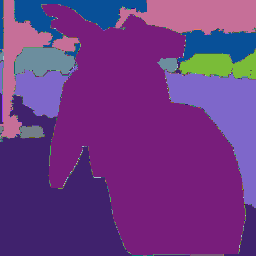

In [ ]:
def show_segmentation(s, show=True):
    s = model.to_rgb(s)
    s = ((s+1.0)*127.5).clip(0,255).to(torch.uint8)
    s = s.detach().cpu().numpy().transpose(0, 2, 3, 1)[0]
    s = Image.fromarray(s)
    if show:
        display(s)
    else:
        return s

show_segmentation(segmentation)

In [30]:
def combine_images_side_by_side(images):
    # Calculate total width and max height
    total_width = sum(img.width for img in images)
    max_height = max(img.height for img in images)

    # Create a new blank image
    combined = Image.new("RGB", (total_width, max_height))

    # Paste each image next to each other
    x_offset = 0
    for img in images:
        combined.paste(img, (x_offset, 0))
        x_offset += img.width

    return combined

def combine_images_top_to_bottom(images):
    # Calculate max width and total height
    max_width = max(img.width for img in images)
    total_height = sum(img.height for img in images)

    # Create a new blank image
    combined = Image.new("RGB", (max_width, total_height))

    # Paste each image on top of each other
    y_offset = 0
    for img in images:
        combined.paste(img, (0, y_offset))
        y_offset += img.height

    return combined

def save_segmentation_examples():
    images = []
    segmentation_images = []
    for i in range(5):
        image = val_ldr.dataset[i]["image"]
        image = ((image+1.0)*127.5).clip(0,255).astype(np.uint8)
        # image = image.transpose(1, 2, 0)
        image = Image.fromarray(image)
        images.append(image)

        segmentation = val_ldr.dataset[i]["segmentation"]
        segmentation = torch.tensor(segmentation.transpose(2,0,1)[None]).to(dtype=torch.float32, device=model.device)
        segmentation_images.append(show_segmentation(segmentation, show=False))
    combined_seg_image = combine_images_side_by_side(segmentation_images)
    combined_image = combine_images_side_by_side(images)
    combined_image = combine_images_top_to_bottom([combined_image, combined_seg_image])
    combined_image.save("analysis/figs/segmentation_examples.png")
save_segmentation_examples()

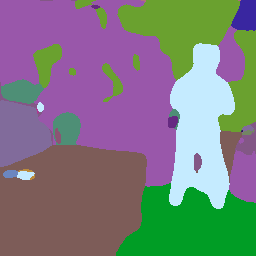

In [11]:
def reconstruct(model, s):
    segmentation_rec, _ = model(s)
    segmentation_rec = torch.argmax(segmentation_rec, dim=1, keepdim=True)
    segmentation_rec = F.one_hot(segmentation_rec, num_classes=s.shape[1])
    segmentation_rec = segmentation_rec.squeeze(1).permute(0,3,1,2).to(torch.float32)
    return segmentation_rec

segmentation_rec = reconstruct(model, segmentation)
show_segmentation(segmentation_rec)

In [12]:
xs = []
xrecs = []
for i, batch in enumerate(tqdm(val_ldr)):
    x = batch["segmentation"].permute(0,3,1,2).to(dtype=torch.float32, device=model.device)
    if x.shape[1] != 183 and x.shape[2] != 256 and x.shape[3] != 256:
        print("skipping batch with wrong number of channels:", x.shape)
        continue

    xrec = reconstruct(model, x)

    xlbl = torch.argmax(x, dim=1)
    xreclbl = torch.argmax(xrec, dim=1)

    assert xlbl.min() >= 0 and xlbl.max() < 183, f"labels out of range: {xlbl.min()} - {xlbl.max()} for {i}"
    assert xreclbl.min() >= 0 and xreclbl.max() < 183, f"reconstructed labels out of range: {xreclbl.min()} - {xreclbl.max()} for {i}"

    xs.append(xlbl.detach().cpu())
    xrecs.append(xreclbl.detach().cpu())

xs = torch.cat(xs, dim=0)
xrecs = torch.cat(xrecs, dim=0)

625it [08:50,  1.18it/s]


In [13]:
xs.min(), xs.max()

(tensor(0), tensor(182))

In [14]:
def calculate_miou(
    pred_indicies: torch.Tensor,
    tgt_indicies: torch.Tensor,
    num_classes: int,
    average: str = 'macro'
) -> float:
    miou_metric = torchmetrics.JaccardIndex(
        task='multiclass',
        num_classes=num_classes,
        average=average
    )

    miou_metric = miou_metric.to(pred_indicies.device)
    miou = miou_metric(pred_indicies, tgt_indicies)
    return miou.item()

miou = calculate_miou(xrecs, xs, num_classes=183)
print(f"mIoU: {miou:.4f}")

mIoU: 0.6999


In [15]:
def calculate_accuracy(
    pred_indices: torch.Tensor,
    tgt_indicies: torch.Tensor,
    num_classes: int,
    average: str | None = None
) -> torch.Tensor:
    accuracy_metric = torchmetrics.Accuracy(
        task='multiclass',
        num_classes=num_classes,
        average=average
    )
    accuracy_metric = accuracy_metric.to(pred_indices.device)
    accuracy = accuracy_metric(pred_indices, tgt_indicies)
    return accuracy

accuracy = calculate_accuracy(xrecs, xs, num_classes=183)
print(f"Accuracy: {accuracy}")

Accuracy: tensor([0.8966, 0.9725, 0.7890, 0.9094, 0.9448, 0.8852, 0.9728, 0.9722, 0.9546,
        0.9038, 0.7172, 0.9009, 0.0000, 0.9155, 0.7939, 0.9144, 0.1721, 0.9687,
        0.9636, 0.9283, 0.9250, 0.9289, 0.9687, 0.9408, 0.9546, 0.9162, 0.0000,
        0.5976, 0.9152, 0.0000, 0.0000, 0.6519, 0.3009, 0.9412, 0.5830, 0.4086,
        0.5064, 0.1778, 0.7058, 0.1645, 0.3391, 0.7354, 0.8114, 0.6997, 0.7655,
        0.0000, 0.6941, 0.8561, 0.5107, 0.4585, 0.4223, 0.9447, 0.8818, 0.8570,
        0.9366, 0.9216, 0.8846, 0.7696, 0.9039, 0.9617, 0.9119, 0.9465, 0.8951,
        0.9447, 0.8628, 0.9765, 0.0000, 0.9752, 0.0000, 0.0000, 0.9612, 0.0000,
        0.9420, 0.9414, 0.4854, 0.7250, 0.8602, 0.9231, 0.8843, 0.9560, 0.0000,
        0.9225, 0.9540, 0.0000, 0.8352, 0.9041, 0.9089, 0.5065, 0.9623, 0.0000,
        0.2146, 0.0000, 0.8467, 0.8012, 0.8117, 0.8361, 0.9550, 0.9110, 0.9283,
        0.8607, 0.8128, 0.9098, 0.8987, 0.2817, 0.5331, 0.7102, 0.9836, 0.8414,
        0.6363, 0.9078, 0.9059

In [16]:
def calculate_f1(
    pred_indices: torch.Tensor,
    tgt_indicies: torch.Tensor,
    num_classes: int,
    average: str = 'macro'
) -> float:
    f1_metric = torchmetrics.F1Score(
        task='multiclass',
        num_classes=num_classes,
        average=average
    )
    f1_metric = f1_metric.to(pred_indices.device)
    f1 = f1_metric(pred_indices, tgt_indicies)
    return f1.item()

In [17]:
def calculate_precision(
    pred_indices: torch.Tensor,
    tgt_indicies: torch.Tensor,
    num_classes: int,
    average: str = 'macro'
) -> float:
    precision_metric = torchmetrics.Precision(
        task='multiclass',
        num_classes=num_classes,
        average=average
    )
    precision_metric = precision_metric.to(pred_indices.device)
    precision = precision_metric(pred_indices, tgt_indicies)
    return precision.item()

In [18]:
def calculate_recall(
    pred_indices: torch.Tensor,
    tgt_indicies: torch.Tensor,
    num_classes: int,
    average: str = 'macro'
) -> float:
    recall_metric = torchmetrics.Recall(
        task='multiclass',
        num_classes=num_classes,
        average=average
    )
    recall_metric = recall_metric.to(pred_indices.device)
    recall = recall_metric(pred_indices, tgt_indicies)
    return recall.item()

In [ ]:
columns = [
    "run",
    "mIoU_macro",
    "accuracy_macro",
    "f1_macro",
    "precision_macro",
    "recall_macro",
]
columns += [f"acc_{labels[i]}" for i in range(len(labels))]


results = {col: None for col in columns}
results["run"] = ckpt_path
results["mIoU_macro"] = calculate_miou(xrecs, xs, num_classes=183, average='macro')
results["accuracy_macro"] = calculate_accuracy(xrecs, xs, num_classes=183, average='macro').item()
results["f1_macro"] = calculate_f1(xrecs, xs, num_classes=183, average='macro')
results["precision_macro"] = calculate_precision(xrecs, xs, num_classes=183, average='macro')
results["recall_macro"] = calculate_recall(xrecs, xs, num_classes=183, average='macro')
per_class_accuracy = calculate_accuracy(xrecs, xs, num_classes=183, average=None)
for i in range(len(labels)):
    results[f"acc_{labels[i]}"] = per_class_accuracy[i].item()

# write to CSV results.csv
results_file = "results.csv"
write_header = not os.path.exists(results_file)
with open(results_file, "a") as f:
    writer = csv.DictWriter(f, fieldnames=columns)
    if write_header:
        writer.writeheader()
    writer.writerow(results)

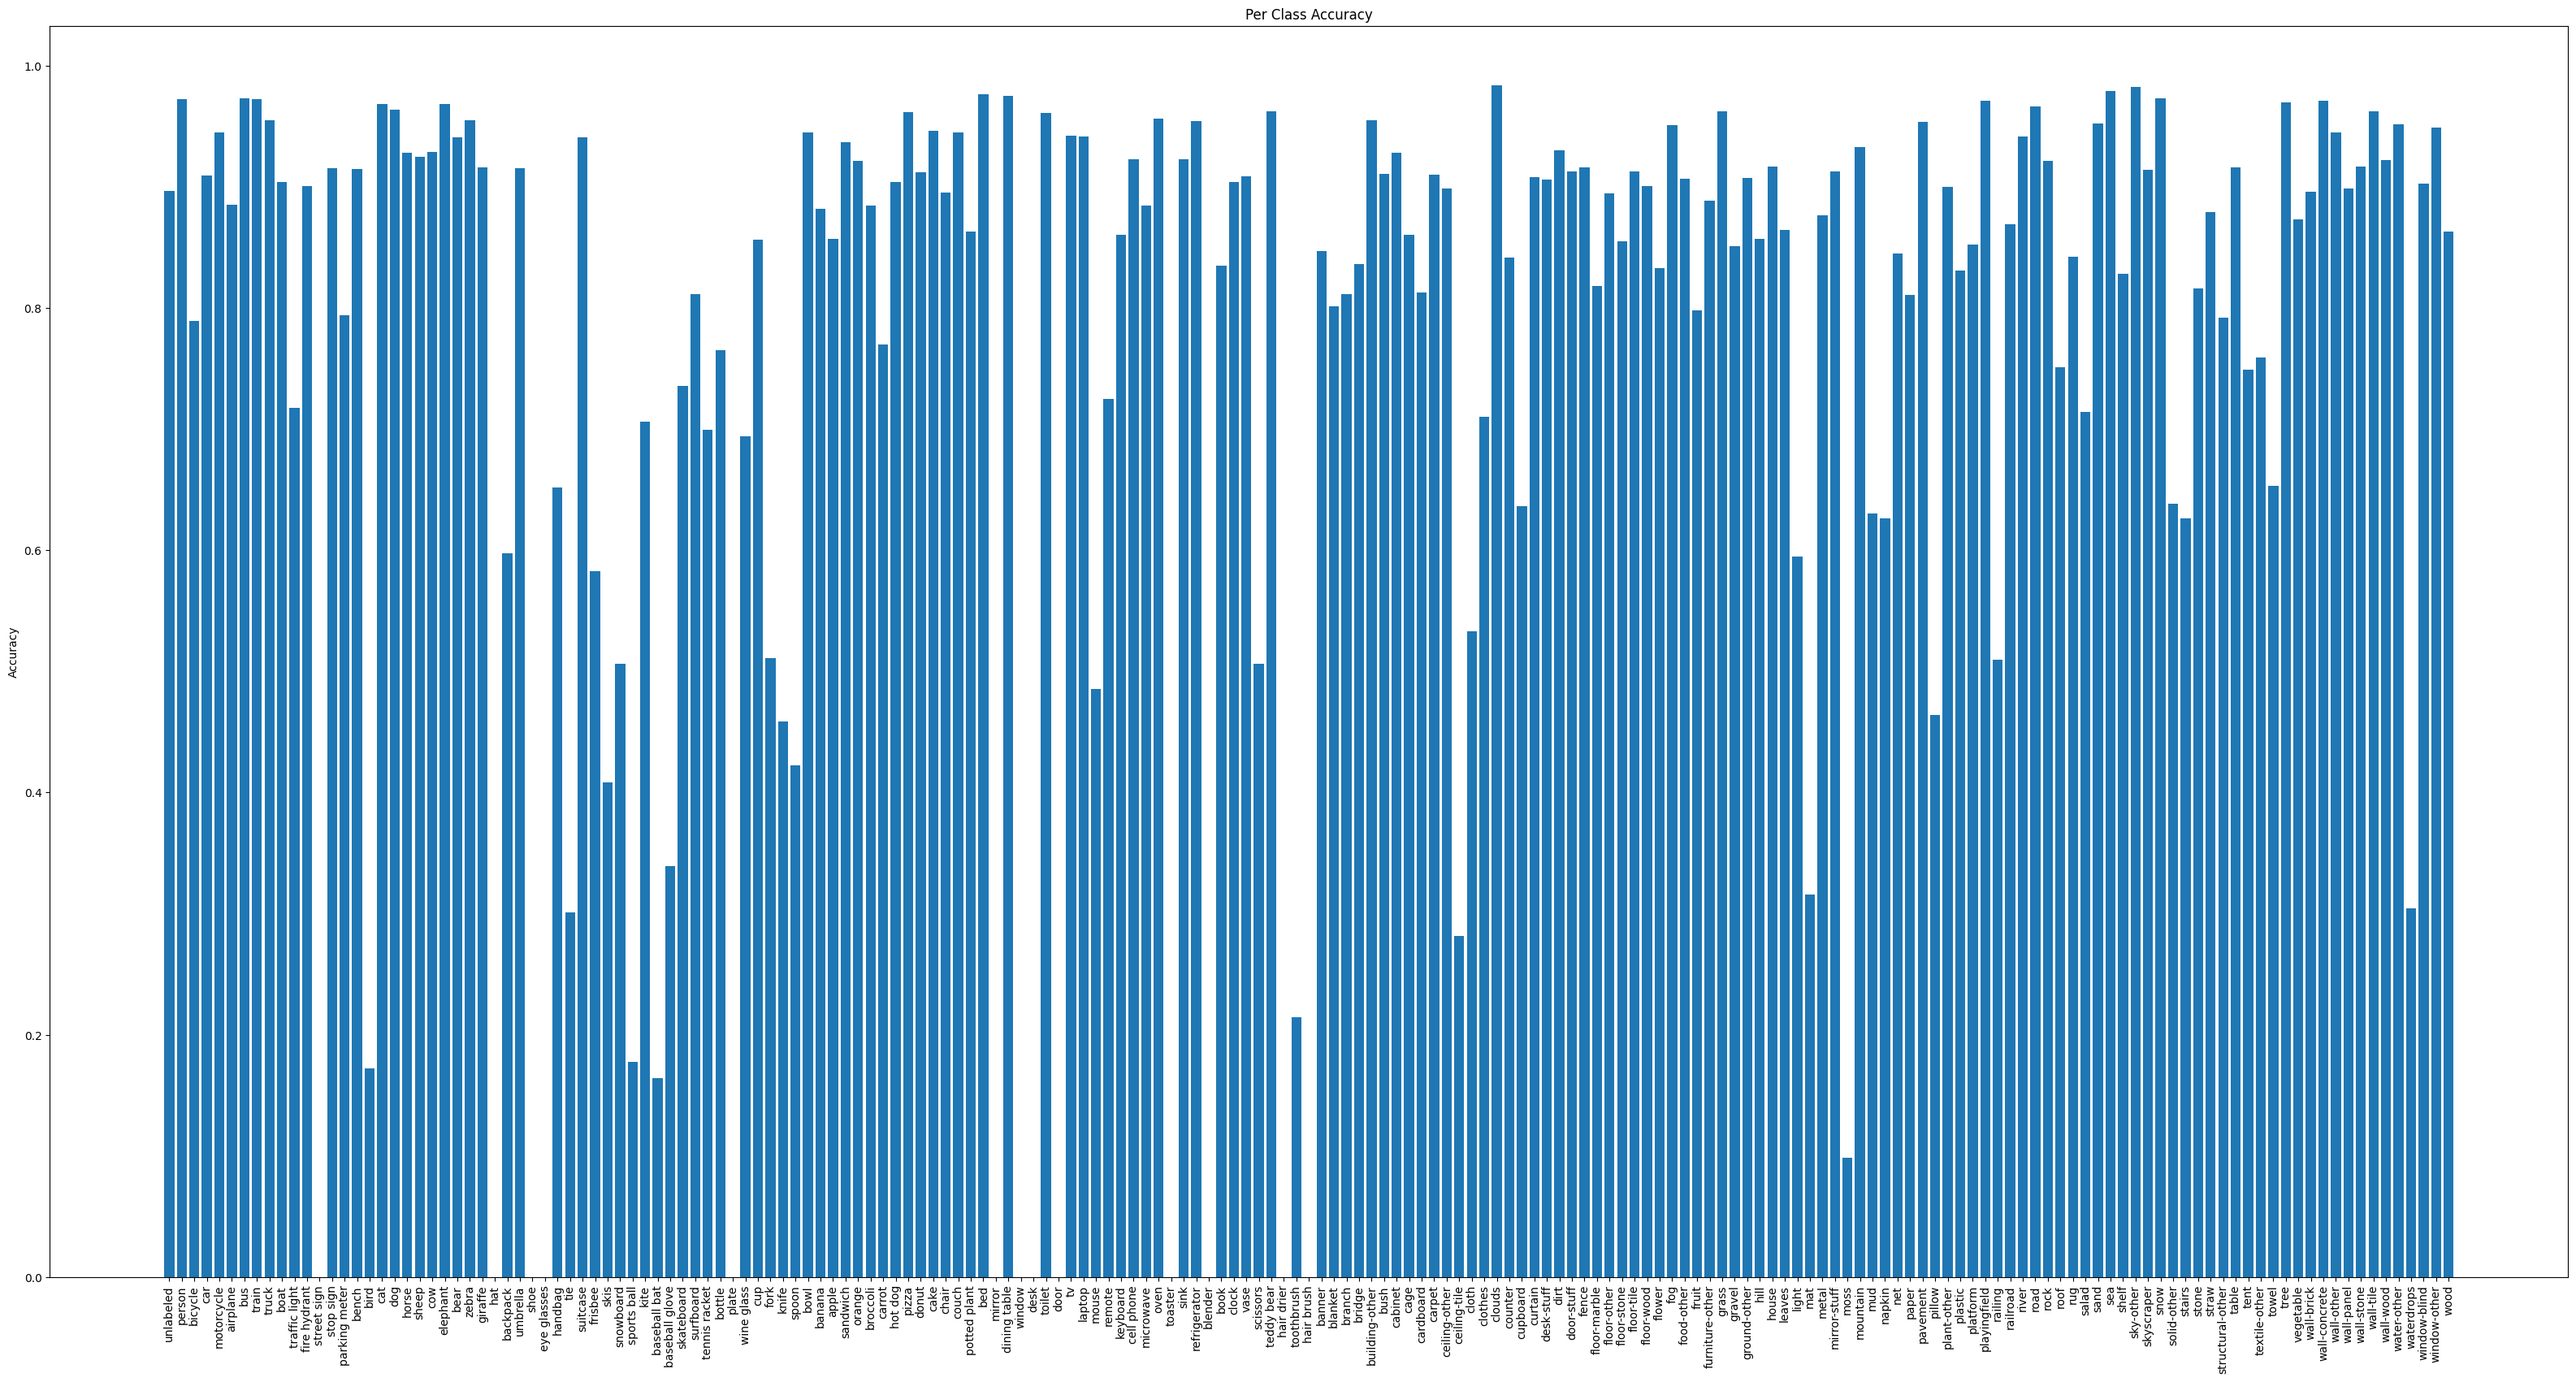

In [23]:
# plot per class accuracy
plt.figure(figsize=(40,20))
plt.bar(range(len(labels)), [results[f"acc_{labels[i]}"] for i in range(len(labels))])
plt.xticks(range(len(labels)), labels, rotation=90)
plt.ylabel("Accuracy")
plt.title("Per Class Accuracy")
plt.show()